#AN2DL

***Second Challenge***

*Marcus.ai*

###Importing

In [23]:
!pip install torch-optimizer -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.6 MB/s eta 0:00:00


In [1]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os
import logging
import random
import numpy as np

np.random.seed(SEED)
random.seed(SEED)


import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
from datetime import datetime
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import v2 as transforms
from torchvision.datasets import VisionDataset
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import GroupShuffleSplit

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p Models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


# Loading Data

In [2]:
!gdown 1jyQtt569_5zcM91dVWxxxOwh-4h9hyxa
!unzip -q bbox_data_cleaned.zip

Downloading...
From (original): https://drive.google.com/uc?id=1jyQtt569_5zcM91dVWxxxOwh-4h9hyxa
From (redirected): https://drive.google.com/uc?id=1jyQtt569_5zcM91dVWxxxOwh-4h9hyxa&confirm=t&uuid=b26f3577-9883-4b07-a986-527d2a52b7ff
To: /content/bbox_data_cleaned.zip
100% 392M/392M [00:06<00:00, 60.2MB/s]


In [3]:
import os, re, glob
import numpy as np
import pandas as pd
from PIL import Image

def load_tiles(tiles_dir, labels_csv=None, size=(224,224), mask_thr=0.05,
               key_col=None, label_col=None):
    lookup = class_names = None
    if labels_csv is not None:
        df = pd.read_csv(labels_csv)

        if label_col is None:
            for c in ["label","class","subtype","target","y"]:
                if c in df.columns: label_col = c; break
            if label_col is None: raise ValueError(f"Label column not found. Columns: {list(df.columns)}")

        if key_col is None:
            # Add 'sample_index' to the list of possible key columns, as identified previously
            key_candidates = ["sample_index"] + [c for c in df.columns if c not in ["sample_index", label_col]]
            if not key_candidates: raise ValueError("No key column found in CSV.")
            key_col = key_candidates[0]

        class_names = list(pd.unique(df[label_col].astype(str)))
        c2i = {c:i for i,c in enumerate(class_names)}
        lookup = dict(zip(df[key_col].astype(str), df[label_col].astype(str).map(c2i)))

    img_paths = sorted(glob.glob(os.path.join(tiles_dir, "img_*_tile_*.png")))
    if not img_paths: raise FileNotFoundError(f"No img_*_tile_*.png in {tiles_dir}")

    N, (W,H) = len(img_paths), size
    X = np.empty((N,3,H,W), np.float32)
    M = np.empty((N,H,W), np.uint8)
    y = np.empty((N,), np.int64) if lookup is not None else None
    img_indices = [] # This list will collect the original image IDs for each tile

    for i,p in enumerate(img_paths):
        stem = os.path.splitext(os.path.basename(p))[0]
        m = re.match(r"img_(\d+)_tile_(\d+)", stem)
        if not m: raise ValueError(f"Bad filename: {os.path.basename(p)}")
        idx = int(m.group(1))
        mp = os.path.join(tiles_dir, stem.replace("img_","mask_",1) + ".png")
        if not os.path.exists(mp): raise FileNotFoundError(f"Missing mask: {mp}")

        im = Image.open(p).convert("RGB").resize(size, Image.BILINEAR)
        X[i] = np.transpose(np.asarray(im, np.float32)/255.0, (2,0,1))

        mk = Image.open(mp).convert("L").resize(size, Image.NEAREST)
        mk = np.asarray(mk, np.float32); mk = mk/255.0 if mk.max()>1 else mk
        M[i] = (mk >= mask_thr).astype(np.uint8)

        # Collect the original image ID for this tile
        original_image_id = f"img_{idx:04d}.png"
        img_indices.append(original_image_id)

        if lookup is not None:
            # The label for a tile is based on its original image ID in the CSV
            # We prioritize looking up the original_image_id in the lookup table.
            keys_to_try = [original_image_id, f"img_{idx:04d}", str(idx)]
            # You can also keep the tile's filename in case your CSV uses it for some reason,
            # but it's less common for image-level labels.
            # keys_to_try.extend([os.path.basename(p), stem])

            found_label = False
            for k in keys_to_try:
                if k in lookup:
                    y[i] = lookup[k];
                    found_label = True
                    break
            if not found_label:
                raise KeyError(f"No label for {os.path.basename(p)} (tried {keys_to_try})")

    if lookup is None:
        return X, M, img_indices # Return collected img_indices for test set
    return (X, M, y, img_indices), class_names # Return collected img_indices for train set

# train
(X_train, X_masks_train, y_train, img_indices_train), class_names = load_tiles(
    "train_tiles_filtered", "train_labels.csv"
)
print(X_train.shape, X_masks_train.shape, y_train.shape, len(img_indices_train), class_names)

# test
X_test, X_masks_test, img_indices_test = load_tiles("test_tiles_filtered")
print(X_test.shape, X_masks_test.shape, len(img_indices_test))


(2776, 3, 224, 224) (2776, 224, 224) (2776,) 2776 ['Triple negative', 'Luminal B', 'Luminal A', 'HER2(+)']
(2063, 3, 224, 224) (2063, 224, 224) 2063


In [5]:
print(f"Number of unique test images: {np.unique(img_indices_test).size}")

Number of unique test images: 477


In [7]:
# Define the input shape and number of classes
input_shape = (3, 224, 224)
num_classes = len(class_names)

print(f"Total Categories for Classification: {num_classes}")
print(f"Computed Input Image Dimensions: {input_shape}")

Total Categories for Classification: 4
Computed Input Image Dimensions: (3, 224, 224)


# 🏋️ Model Training

In [11]:
# ============================================================
# Image-wise stratified split (keeps masks aligned)
# ============================================================

def split_train_val_by_image_stratified(X, X_masks, y, img_indices, val_size=0.2, random_state=42):
    """
    Split patches into train/val by *image id* (stratified by image label),
    while keeping X, masks, labels, and indices perfectly aligned.
    """
    img_indices_arr = np.asarray(img_indices)
    y_arr = np.asarray(y)

    # Unique image ids + one representative label per image
    unique_imgs, first_pos = np.unique(img_indices_arr, return_index=True)
    img_labels = y_arr[first_pos]

    # Stratified split at image level
    tr_imgs, va_imgs = train_test_split(
        unique_imgs,
        test_size=val_size,
        random_state=random_state,
        stratify=img_labels,
    )

    tr_set, va_set = set(tr_imgs), set(va_imgs)

    # Boolean selectors for patches
    sel_tr = np.fromiter((i in tr_set for i in img_indices_arr), dtype=bool, count=len(img_indices_arr))
    sel_va = ~sel_tr  # since tr_set and va_set partition unique_imgs

    # Pack outputs
    train_pack = (
        X[sel_tr],
        X_masks[sel_tr],
        y_arr[sel_tr],
        img_indices_arr[sel_tr],
    )
    val_pack = (
        X[sel_va],
        X_masks[sel_va],
        y_arr[sel_va],
        img_indices_arr[sel_va],
    )

    return train_pack, val_pack


In [39]:
train_set, val_set = split_train_val_by_image_stratified(
    X_train,
    X_masks_train,
    y_train,
    img_indices_train,
    val_size=0.2,
    random_state=SEED,
)

X_train_split, X_masks_train_split, y_train_split, idx_tr = train_set
X_val_split,   X_masks_val_split,   y_val_split,   idx_val = val_set


In [13]:
# --- Dataset shapes (train vs val) ---
train_shapes = (
    X_train_split.shape,
    X_masks_train_split.shape,
    y_train_split.shape
)
val_shapes = (
    X_val_split.shape,
    X_masks_val_split.shape,
    y_val_split.shape
)

print(
    f"X_train shape: {train_shapes[0]}, "
    f"X_masks_train shape: {train_shapes[1]}, "
    f"y_train shape: {train_shapes[2]}"
)
print(
    f"X_val shape: {val_shapes[0]}, "
    f"X_masks_val shape: {val_shapes[1]}, "
    f"y_val shape: {val_shapes[2]}"
)


X_train shape: (2189, 3, 224, 224), X_masks_train shape: (2189, 224, 224), y_train shape: (2189,)
X_val shape: (587, 3, 224, 224), X_masks_val shape: (587, 224, 224), y_val shape: (587,)


In [15]:
# --- Constants ---
BATCH_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
GLOBAL_MEAN_COLOR = (178, 175, 174)


class AutoAugmentStrategy:

    _BILINEAR = transforms.InterpolationMode.BILINEAR

    def __init__(self, strategy="randaugment", global_mean_color=GLOBAL_MEAN_COLOR, **kwargs):
        self.strategy = (strategy or "none").lower() if isinstance(strategy, str) else strategy
        self.fill = global_mean_color
        self.kwargs = dict(kwargs)
        self.transform = self._make()

    def _make(self):
        s = self.strategy
        fill = self.fill

        builders = {
            "randaugment": lambda: transforms.RandAugment(
                num_ops=self.kwargs.get("num_ops", 2),
                magnitude=self.kwargs.get("magnitude", 9),
                interpolation=self._BILINEAR,
                fill=fill,
            ),
            "trivialaugment": lambda: transforms.TrivialAugmentWide(
                interpolation=self._BILINEAR,
                fill=fill,
            ),
            "autoaugment": lambda: transforms.AutoAugment(
                policy=transforms.AutoAugmentPolicy.IMAGENET,
                interpolation=self._BILINEAR,
                fill=fill,
            ),
            "custom": lambda: transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomAffine(
                    degrees=(-180, 180),
                    translate=(0.1, 0.1),
                    scale=(0.8, 1.2),
                    interpolation=self._BILINEAR,
                    fill=fill,
                ),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
            ]),
            "none": lambda: (lambda x: x),
        }

        if s in builders:
            return builders[s]()

    def __call__(self, img):
        return self.transform(img)


In [38]:
class OgresDatasetDualPath(Dataset):
    def __init__(
        self,
        images,
        masks,
        labels,
        augmentation_strategy="custom",
        num_augmentations=4,
        normalize_imagenet=True,
    ):
        self._img = torch.as_tensor(images, dtype=torch.float32)
        self._msk = torch.as_tensor(masks, dtype=torch.float32)
        self._lbl = torch.as_tensor(labels, dtype=torch.long)

        self._n = self._img.shape[0]
        self._k = int(num_augmentations)

        self._use_aug = augmentation_strategy not in (None, "none")
        self._aug = AutoAugmentStrategy(strategy=augmentation_strategy) if self._use_aug else None

        self._norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD) if normalize_imagenet else None

        self._to_pil = transforms.ToPILImage()
        self._to_tensor = transforms.ToTensor()

    def __len__(self):
        return self._n * (self._k + 1) if self._use_aug else self._n

    def _split_index(self, idx: int):
        base = idx % self._n
        is_orig = idx < self._n
        return base, is_orig

    def __getitem__(self, idx):
        base_idx, is_original = self._split_index(int(idx))

        img = self._img[base_idx].clone()      # (C,H,W)
        msk = self._msk[base_idx].clone()      # (H,W) or (1,H,W)
        lbl = self._lbl[base_idx]

        if msk.ndim == 2:
            msk = msk.unsqueeze(0)

        if (not is_original) and (self._aug is not None):
            pil = self._to_pil(torch.clamp(img, 0.0, 1.0)).convert("RGB")
            pil = self._aug(pil)
            img = self._to_tensor(pil)

        if self._norm is not None:
            img = self._norm(img)

        msk = (msk > 0.5).to(torch.float32)

        return img, msk, lbl


In [18]:
# MixUp augmentation (use inside training loop)
def mixup(inputs, targets, alpha=0.1):
    """
    MixUp: returns mixed_inputs, targets_a, targets_b, lambda.
    """
    if alpha is None or alpha <= 0:
        return inputs, targets, targets, 1.0

    lam = float(np.random.beta(alpha, alpha))
    n = inputs.size(0)

    perm = torch.randperm(n, device=inputs.device)
    mixed = inputs.mul(lam).add(inputs[perm].mul(1.0 - lam))

    ta = targets
    tb = targets[perm]
    return mixed, ta, tb, lam


In [27]:
def make_data_loader(dataset, batch_size, shuffle=True, drop_last=False):
    cores = os.cpu_count() or 2
    workers = max(2, min(4, cores))

    use_cuda = torch.cuda.is_available()
    pin_dev = "cuda" if use_cuda else None

    loader_kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=workers,
        pin_memory=use_cuda,
        prefetch_factor=4,
    )

    try:
        if use_cuda:
            loader_kwargs["pin_memory_device"] = pin_dev
        return DataLoader(dataset, **loader_kwargs)
    except TypeError:
        loader_kwargs.pop("pin_memory_device", None)
        return DataLoader(dataset, **loader_kwargs)


##   **Parameters**

In [20]:
LEARNING_RATE    = 1e-3
LEARNING_RATE_FT = 1e-4
EPOCHS           = 100
PATIENCE         = 20

DROPOUT_RATE     = 0.2
L2               = 0.01
LABEL_SMOOTHING  = 0.05


counts = np.bincount(np.asarray(y_train_split))
inv = 1.0 / np.maximum(counts, 1)
class_weights = inv / inv.sum()

weight_tensor = torch.as_tensor(class_weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(
    weight=weight_tensor,
    label_smoothing=LABEL_SMOOTHING
)

cfg = {
    "Epochs": EPOCHS,
    "Batch Size": BATCH_SIZE,
    "Initial Learning Rate": LEARNING_RATE,
    "Fine-tuning Learning Rate": LEARNING_RATE_FT,
    "Dropout Rate": DROPOUT_RATE,
    "L2 Regularization": L2,
    "Label Smoothing": LABEL_SMOOTHING,
    "Patience for Early Stopping": PATIENCE,
    "Class Weights": class_weights,
}

print("\n--- Training Configuration ---")
for k, v in cfg.items():
    print(f"{k}: {v}")
print("-" * 28)



--- Training Configuration ---
Epochs: 100
Batch Size: 64
Initial Learning Rate: 0.001
Fine-tuning Learning Rate: 0.0001
Dropout Rate: 0.2
L2 Regularization: 0.01
Label Smoothing: 0.05
Patience for Early Stopping: 20
Class Weights: [0.45845026 0.14846187 0.19165981 0.20142806]
----------------------------


##   **Training Functions for Model**

In [21]:
def _run_epoch_dual(
    model, loader, criterion, device,
    optimizer=None, scaler=None, mixup_alpha=0.2
):
    is_train = optimizer is not None
    model.train(mode=is_train)

    total_loss, seen = 0.0, 0
    preds_buf, targs_buf = [], []

    amp_on = (device.type == "cuda")
    autocast = torch.amp.autocast

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, msks, targs in loader:
            imgs = imgs.to(device, non_blocking=True)
            msks = msks.to(device, non_blocking=True)
            targs = targs.to(device, non_blocking=True)

            if is_train:
                imgs_mix, ta, tb, lam = mixup(imgs, targs, alpha=mixup_alpha)
                optimizer.zero_grad(set_to_none=True)

                with autocast(device_type=device.type, enabled=amp_on):
                    out = model(imgs_mix, msks)
                    loss = lam * criterion(out, ta) + (1.0 - lam) * criterion(out, tb)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast(device_type=device.type, enabled=amp_on):
                    out = model(imgs, msks)
                    loss = criterion(out, targs)

            bs = imgs.size(0)
            total_loss += float(loss.detach()) * bs
            seen += bs

            preds_buf.append(out.argmax(dim=1).detach().cpu().numpy())
            targs_buf.append(targs.detach().cpu().numpy())

    y_true = np.concatenate(targs_buf) if targs_buf else np.array([])
    y_pred = np.concatenate(preds_buf) if preds_buf else np.array([])

    epoch_loss = total_loss / max(seen, 1)
    epoch_acc = accuracy_score(y_true, y_pred) if y_true.size else 0.0
    epoch_f1  = f1_score(y_true, y_pred, average="weighted") if y_true.size else 0.0

    return epoch_loss, epoch_acc, epoch_f1


def train_one_epoch_dual(model, train_loader, criterion, optimizer, scaler, device, mixup_alpha=0.2):
    return _run_epoch_dual(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=device,
        optimizer=optimizer,
        scaler=scaler,
        mixup_alpha=mixup_alpha,
    )


def validate_one_epoch_dual(model, val_loader, criterion, device):
    return _run_epoch_dual(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        optimizer=None,
        scaler=None,
        mixup_alpha=0.0,
    )


def fit_dual(
    model,
    train_loader,
    val_loader,
    epochs,
    criterion,
    optimizer,
    scaler,
    device,
    scheduler=None,
    patience=0,
    evaluation_metric="val_f1",
    mode="max",
    restore_best_weights=True,
    writer=None,
    verbose=1,
    experiment_name="",
):
    hist = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","train_f1","val_f1"]}

    best_metric = float("-inf") if mode == "max" else float("inf")
    best_epoch = 0
    wait = 0

    ckpt_path = os.path.join("Models", f"{experiment_name}_model.pt")

    print(f"Training {epochs} epochs...")

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch_dual(
            model, train_loader, criterion, optimizer, scaler, device
        )
        va_loss, va_acc, va_f1 = validate_one_epoch_dual(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step(va_f1)

        hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc);   hist["val_acc"].append(va_acc)
        hist["train_f1"].append(tr_f1);     hist["val_f1"].append(va_f1)

        if writer is not None:
            writer.add_scalar("Loss/Training", tr_loss, ep)
            writer.add_scalar("Loss/Validation", va_loss, ep)
            writer.add_scalar("Accuracy/Training", tr_acc, ep)
            writer.add_scalar("Accuracy/Validation", va_acc, ep)
            writer.add_scalar("F1/Training", tr_f1, ep)
            writer.add_scalar("F1/Validation", va_f1, ep)

        if verbose and (ep == 1 or ep % verbose == 0):
            print(
                f"Epoch {ep:3d}/{epochs} | "
                f"Train: Loss={tr_loss:.4f}, Acc={tr_acc:.4f}, F1={tr_f1:.4f} | "
                f"Val: Loss={va_loss:.4f}, Acc={va_acc:.4f}, F1={va_f1:.4f}"
            )

        if patience > 0:
            metric_now = hist[evaluation_metric][-1]
            improved = (metric_now > best_metric) if mode == "max" else (metric_now < best_metric)

            if improved:
                best_metric, best_epoch = metric_now, ep
                torch.save(model.state_dict(), ckpt_path)
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping triggered after {ep} epochs.")
                    break

    if patience == 0:
        torch.save(model.state_dict(), ckpt_path)

    if restore_best_weights and patience > 0 and os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    if writer is not None:
        writer.close()

    return model, hist


In [22]:
class DualPathEfficientNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5, freeze_rgb_backbone=False):
        super().__init__()

        backbone = torchvision.models.efficientnet_b2(
            weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT
        )

        if freeze_rgb_backbone:
            backbone.requires_grad_(False)

        rgb_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()

        self.rgb_backbone = backbone
        self.rgb_features = rgb_dim

        self.mask_encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.mask_features = 256

        fused_dim = self.rgb_features + self.mask_features
        self.fusion_classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(fused_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, rgb_image, mask):
        # Feature extraction
        feat_rgb = self.rgb_backbone(rgb_image)
        feat_msk = self.mask_encoder(mask)

        # Late fusion (concat)
        fused = torch.cat((feat_rgb, feat_msk), dim=1)

        return self.fusion_classifier(fused)


In [25]:
import torch_optimizer as optim


ft_model = DualPathEfficientNet(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    freeze_rgb_backbone=False,
).to(device)


ft_model.requires_grad_(False)

ft_model.fusion_classifier.requires_grad_(True)
ft_model.mask_encoder.requires_grad_(True)

for block_idx in (7, 8):
    ft_model.rgb_backbone.features[block_idx].requires_grad_(True)

rgb_params, mask_params, fusion_params = [], [], []

for n, p in ft_model.named_parameters():
    if not p.requires_grad:
        continue
    if n.startswith("rgb_backbone."):
        rgb_params.append(p)
    elif n.startswith("mask_encoder."):
        mask_params.append(p)
    elif n.startswith("fusion_classifier."):
        fusion_params.append(p)


optimizer = optim.Ranger(
    [
        {"params": rgb_params, "lr": LEARNING_RATE_FT},
        {"params": mask_params, "lr": LEARNING_RATE},
        {"params": fusion_params, "lr": LEARNING_RATE},
    ],
    weight_decay=L2,
)


def _count_params(params):
    return sum(p.numel() for p in params)

total_params = _count_params(ft_model.parameters())
trainable_params = _count_params(p for p in ft_model.parameters() if p.requires_grad)


In [28]:
print("\n[1/2] Preparing datasets...")

train_cfg = dict(
    augmentation_strategy="custom",
    num_augmentations=4,
    normalize_imagenet=True,
)
val_cfg = dict(
    augmentation_strategy=None,
    normalize_imagenet=True,
)

train_ds = OgresDatasetDualPath(X_train_split, X_masks_train_split, y_train_split, **train_cfg)
val_ds   = OgresDatasetDualPath(X_val_split,   X_masks_val_split,   y_val_split,   **val_cfg)

print("[2/2] Preparing dataloaders...")
train_loader = make_data_loader(dataset=train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = make_data_loader(dataset=val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)



[1/2] Preparing datasets...
[2/2] Preparing dataloaders...


In [29]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
    threshold=1e-3,
    threshold_mode="abs",
    cooldown=1,
    min_lr=1e-6,
)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

experiment_name = "fusion_efficientnet_b2"
writer = SummaryWriter(log_dir=os.path.join(logs_dir, experiment_name))


In [31]:
%%time

train_args = dict(
    model=ft_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    scheduler=scheduler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    evaluation_metric="val_f1",
)

ft_model, ft_history = fit_dual(**train_args)


best_val_acc = max(ft_history["val_acc"]) if ft_history["val_acc"] else 0.0
best_val_f1  = max(ft_history["val_f1"])  if ft_history["val_f1"]  else 0.0

print(f"Final validation accuracy: {best_val_acc * 100:.2f}%")
print(f"Final validation F1: {best_val_f1 * 100:.2f}%")


Training 100 epochs...
Epoch   1/100 | Train: Loss=1.3647, Acc=0.2856, F1=0.2906 | Val: Loss=1.3517, Acc=0.3169, F1=0.2921
Epoch   2/100 | Train: Loss=1.2839, Acc=0.3519, F1=0.3528 | Val: Loss=1.3964, Acc=0.3475, F1=0.3333
Epoch   3/100 | Train: Loss=1.2159, Acc=0.3852, F1=0.3868 | Val: Loss=1.4269, Acc=0.3697, F1=0.3725
Epoch   4/100 | Train: Loss=1.1626, Acc=0.4144, F1=0.4164 | Val: Loss=1.4720, Acc=0.3186, F1=0.2671
Epoch   5/100 | Train: Loss=1.1110, Acc=0.4697, F1=0.4698 | Val: Loss=1.4591, Acc=0.3816, F1=0.3704
Epoch   6/100 | Train: Loss=1.0652, Acc=0.5083, F1=0.5100 | Val: Loss=1.4518, Acc=0.3714, F1=0.3609
Epoch   7/100 | Train: Loss=1.0406, Acc=0.5288, F1=0.5313 | Val: Loss=1.5080, Acc=0.3646, F1=0.3539
Epoch   8/100 | Train: Loss=0.9686, Acc=0.5667, F1=0.5689 | Val: Loss=1.4977, Acc=0.3663, F1=0.3441
Epoch   9/100 | Train: Loss=0.9612, Acc=0.5858, F1=0.5886 | Val: Loss=1.5013, Acc=0.4003, F1=0.3940
Epoch  10/100 | Train: Loss=0.9150, Acc=0.6249, F1=0.6270 | Val: Loss=1.4899,

## tracking Training History loss and accuracy and F1 score

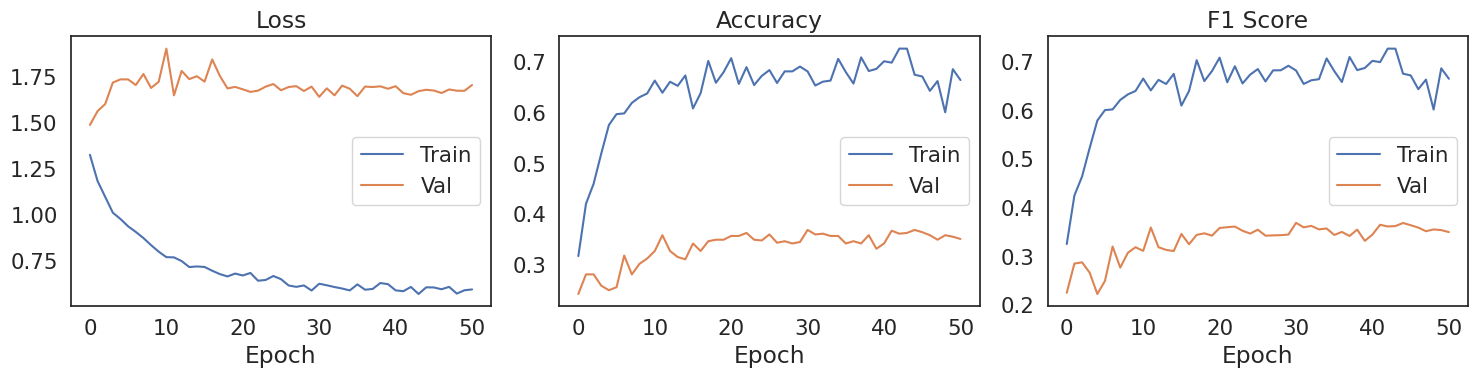

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ft_history['train_loss'], label='Train')
axes[0].plot(ft_history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ft_history['train_acc'], label='Train')
axes[1].plot(ft_history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()


axes[2].plot(ft_history['train_f1'], label='Train')
axes[2].plot(ft_history['val_f1'], label='Val')
axes[2].set_title('F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

#  Inference

In [32]:
def aggregate_patch_predictions_weighted(all_logits, all_img_indices, patch_scores=None, method="mean"):
    probs = torch.softmax(all_logits, dim=1).detach().cpu().numpy()
    img_idx = np.asarray(all_img_indices)

    groups = {}
    for i, img_id in enumerate(img_idx):
        if img_id not in groups:
            groups[img_id] = {"p": [], "w": []}
        groups[img_id]["p"].append(probs[i])
        if patch_scores is not None:
            groups[img_id]["w"].append(patch_scores[i])

    img_ids = np.array(sorted(groups.keys()))
    out_probs = []

    for img_id in img_ids:
        P = np.stack(groups[img_id]["p"], axis=0)

        if method == "mean":
            agg = P.mean(axis=0)

        elif method == "weighted_mean":
            w = np.asarray(groups[img_id]["w"], dtype=np.float32)
            w_sum = float(w.sum())
            if w_sum <= 0:
                agg = P.mean(axis=0)
            else:
                agg = (P * w[:, None]).sum(axis=0) / w_sum

        elif method == "max_confidence":
            pick = int(P.max(axis=1).argmax())
            agg = P[pick]

        elif method == "majority_vote":
            votes = P.argmax(axis=1)
            maj = int(np.bincount(votes).argmax())
            agg = np.zeros(P.shape[1], dtype=np.float32)
            agg[maj] = 1.0

        else:
            raise ValueError(f"Unknown method: {method!r}")

        out_probs.append(agg)

    out_probs = np.stack(out_probs, axis=0)
    out_preds = out_probs.argmax(axis=1)

    return img_ids, out_probs, out_preds


In [33]:
# Load best model
best_model = DualPathEfficientNet(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    freeze_rgb_backbone=False
).to(device)

best_model.load_state_dict(torch.load("Models/" + experiment_name + "_model.pt", map_location=device))
best_model.eval()


# generate submission

In [35]:
class TestDatasetDualPath(Dataset):

    def __init__(self, images, masks, normalize_imagenet=True):
        self._img = torch.as_tensor(images, dtype=torch.float32)
        self._msk = torch.as_tensor(masks, dtype=torch.float32)

        self._norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD) if normalize_imagenet else None

    def __len__(self):
        return int(self._img.shape[0])

    def __getitem__(self, idx):
        img = self._img[idx].clone()
        msk = self._msk[idx].clone()

        if msk.ndim == 2:
            msk = msk.unsqueeze(0)

        if self._norm is not None:
            img = self._norm(img)

        msk = (msk > 0.5).to(torch.float32)
        return img, msk


test_ds = TestDatasetDualPath(X_test, X_masks_test, normalize_imagenet=True)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)


In [36]:
GLOBAL_MEAN_COLOR = (178, 175, 174)
TTA_STEPS = 16


class TTAAugmentStrategy:

    _interp = transforms.InterpolationMode.BILINEAR

    def __init__(self, strategy="custom", global_mean_color=GLOBAL_MEAN_COLOR, **kwargs):
        self.strategy = (strategy or "none").lower() if isinstance(strategy, str) else strategy
        self.fill = global_mean_color
        self.kwargs = dict(kwargs)
        self.transform = self._make_transform()

    def _make_transform(self):
        s = self.strategy
        fill = self.fill

        if s == "randaugment":
            return transforms.RandAugment(
                num_ops=self.kwargs.get("num_ops", 1),
                magnitude=self.kwargs.get("magnitude", 5),
                interpolation=self._interp,
                fill=fill,
            )
        if s == "trivialaugment":
            return transforms.TrivialAugmentWide(interpolation=self._interp, fill=fill)
        if s == "custom":
            return transforms.Compose([
                transforms.RandomAffine(
                    degrees=(-30, 30),
                    translate=(0.05, 0.05),
                    scale=(0.9, 1.1),
                    interpolation=self._interp,
                    fill=fill,
                ),
                transforms.ColorJitter(brightness=0.05, contrast=0.05),
            ])
        if s in ("none", None):
            return lambda x: x

    def __call__(self, img):
        return self.transform(img)


tta_transform = TTAAugmentStrategy(strategy="custom")

_IM_MEAN = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
_IM_STD  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

_to_pil = transforms.ToPILImage()
_to_tensor = transforms.ToTensor()
_norm_imagenet = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

def normalized_tensor_to_pil(img_norm):
    x = img_norm.detach().cpu()
    x = (x * _IM_STD) + _IM_MEAN
    x = torch.clamp(x, 0.0, 1.0)
    return _to_pil(x)


best_model.eval()

logits_chunks = []
mapped_img_indices = []

ptr = 0
with torch.no_grad():
    for imgs, msks in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        msks = msks.to(device, non_blocking=True)

        passes = [best_model(imgs, msks)]

        bsz = imgs.size(0)
        for _ in range(TTA_STEPS):
            aug_list = []
            for j in range(bsz):
                pil = normalized_tensor_to_pil(imgs[j])
                pil_aug = tta_transform(pil)
                t = _to_tensor(pil_aug)
                aug_list.append(t)

            aug_batch = torch.stack(aug_list, dim=0).to(device, non_blocking=True)
            aug_batch = _norm_imagenet(aug_batch)

            passes.append(best_model(aug_batch, msks))

        mean_logits = torch.stack(passes, dim=0).mean(dim=0)
        logits_chunks.append(mean_logits.cpu())

        mapped_img_indices.extend(img_indices_test[ptr:ptr + bsz])
        ptr += bsz

all_logits_test = torch.cat(logits_chunks, dim=0)

unique_img_ids_test, img_probs_test, img_preds_test = aggregate_patch_predictions_weighted(
    all_logits_test,
    mapped_img_indices,
    patch_scores=None,
    method="mean",
)


In [37]:
# Create submission file
submission_image_names = unique_img_ids_test
predicted_labels = [class_names[i] for i in img_preds_test]

submission_df = pd.DataFrame({
    "sample_index": submission_image_names,
    "label": predicted_labels
})

output_path = f"/content/test_mo.csv"

submission_df.to_csv(output_path, index=False)

print(f"Submission file saved")

Submission file saved
